In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from torchvision.datasets import EMNIST
from torchvision import transforms

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Ambiente carregado com sucesso!")

TensorFlow: 2.20.0
Ambiente carregado com sucesso!


In [2]:
#Carregamento do EMNIST ByClass
transform = transforms.ToTensor()

train_raw = EMNIST(
    root="./data",
    split="byclass",
    train=True,
    download=True,
    transform=transform
)

test_raw = EMNIST(
    root="./data",
    split="byclass",
    train=False,
    download=True,
    transform=transform
)

print("EMNIST carregado com sucesso!")
print("Amostras de treino:", len(train_raw))
print("Amostras de teste:", len(test_raw))
print("Número de classes:", len(train_raw.classes))

100%|██████████| 562M/562M [00:07<00:00, 77.1MB/s]


EMNIST carregado com sucesso!
Amostras de treino: 697932
Amostras de teste: 116323
Número de classes: 62


In [3]:
#Conversão para NumPy e correção da orientação
def dataset_to_numpy(dataset):
    images = []
    labels = []

    for image, label in dataset:
        image = image.squeeze(0).numpy()

        image = np.fliplr(image.T)

        images.append(image)
        labels.append(label)

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int64)

    #Adiciona canal: (28,28) -> (28,28,1)
    images = np.expand_dims(images, axis=-1)

    return images, labels

In [4]:
x_train_all, y_train_all = dataset_to_numpy(train_raw)
x_test_all, y_test_all = dataset_to_numpy(test_raw)

print("Treino:", x_train_all.shape, y_train_all.shape)
print("Teste:", x_test_all.shape, y_test_all.shape)

Treino: (697932, 28, 28, 1) (697932,)
Teste: (116323, 28, 28, 1) (116323,)


In [5]:
CLASS_CONFIGS = {
    "digitos": {
        "labels": [1, 2, 3, 4, 5],
        "names": ["1", "2", "3", "4", "5"]
    },

    "letras": {
        "labels": [10, 11, 12, 13, 14],
        "names": ["A", "B", "C", "D", "E"]
    },

    "vf": {
        "labels": [31, 15],  # V e F
        "names": ["V", "F"]
    }
}

In [6]:
def criar_subconjunto(x, y, labels_desejados):
    mascara = np.isin(y, labels_desejados)

    x_sub = x[mascara]
    y_sub = y[mascara]

    mapa = {
        label_original: nova_classe
        for nova_classe, label_original in enumerate(labels_desejados)
    }

    y_sub = np.array(
        [mapa[label] for label in y_sub],
        dtype=np.int64
    )

    return x_sub, y_sub

In [7]:
datasets = {}

for nome, config in CLASS_CONFIGS.items():

    x_train, y_train = criar_subconjunto(
        x_train_all,
        y_train_all,
        config["labels"]
    )

    x_test, y_test = criar_subconjunto(
        x_test_all,
        y_test_all,
        config["labels"]
    )

    datasets[nome] = {
        "x_train": x_train,
        "y_train": y_train,
        "x_test": x_test,
        "y_test": y_test
    }

    print(
        nome,
        "| treino:", x_train.shape,
        "| teste:", x_test.shape
    )

digitos | treino: (172671, 28, 28, 1) | teste: (28977, 28, 28, 1)
letras | treino: (29875, 28, 28, 1) | teste: (5079, 28, 28, 1)
vf | treino: (13819, 28, 28, 1) | teste: (2236, 28, 28, 1)


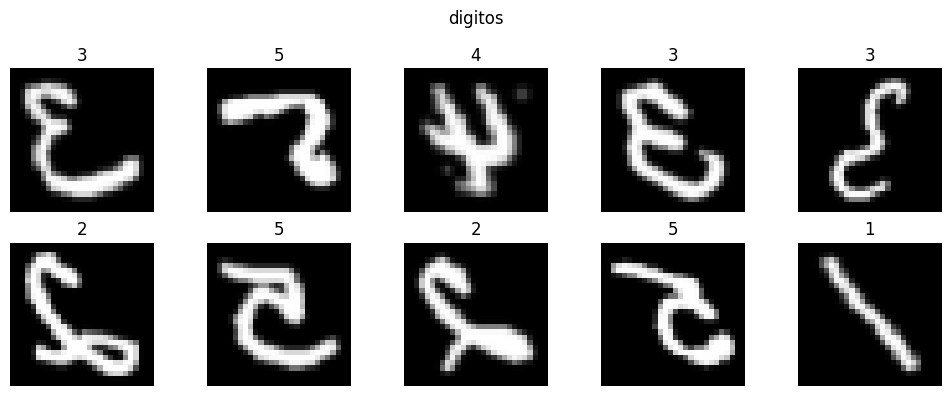

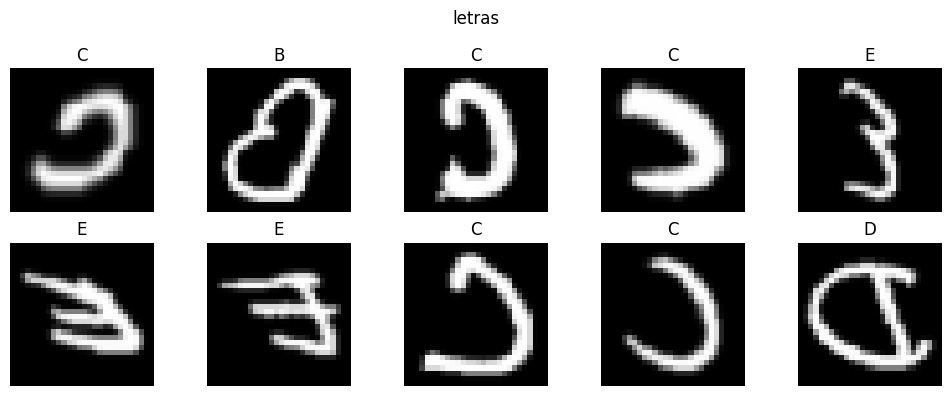

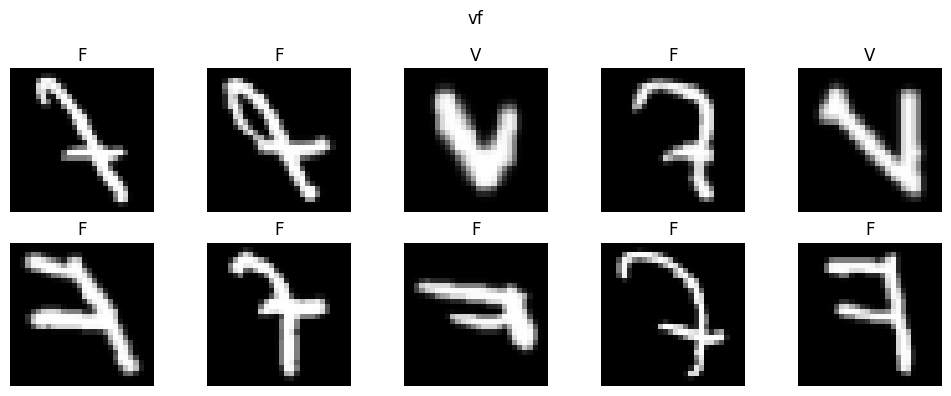

In [8]:
def mostrar_amostras(x, y, nomes, titulo):
    plt.figure(figsize=(10,4))

    n = min(10, len(x))

    for i in range(n):
        plt.subplot(2,5,i+1)
        plt.imshow(x[i].squeeze(), cmap="gray")
        plt.title(nomes[int(y[i])])
        plt.axis("off")

    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()

for nome, config in CLASS_CONFIGS.items():
    mostrar_amostras(
        datasets[nome]["x_train"],
        datasets[nome]["y_train"],
        config["names"],
        nome
    )

In [9]:
def build_cnn(num_classes, task="digits_letters",
              filters=(32, 32, 64, 64),
              kernel_size=3,
              learning_rate=0.001):

    model = keras.Sequential()
    model.add(layers.Input(shape=(28, 28, 1)))

    blocks = 4 if task == "digits_letters" else 3

    for i in range(blocks):
        model.add(
            layers.Conv2D(
                filters=filters[i],
                kernel_size=kernel_size,
                padding="same",
                activation="relu"
            )
        )
        model.add(
            layers.MaxPooling2D(pool_size=(2,2))
        )

    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation="relu"))
    model.add(layers.Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [10]:
models = {
    "digitos": build_cnn(
        5,
        task="digits_letters",
        filters=(32, 32, 64, 64)
    ),

    "letras": build_cnn(
        5,
        task="digits_letters",
        filters=(32, 32, 64, 64)
    ),

    "vf": build_cnn(
        2,
        task="vf",
        filters=(32, 32, 64, 64)
    )
}

for nome, model in models.items():
    print("\n", "="*70)
    print(nome.upper())
    model.summary()


DIGITOS


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,477 (271.39 KB)

 Trainable params: 69,477 (271.39 KB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,122 (254.38 KB)

 Trainable params: 65,122 (254.38 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
histories = {}

for nome, model in models.items():

    epochs = 20 if nome in ("digitos", "letras") else 10

    print("\nTREINANDO:", nome.upper())

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ]

    histories[nome] = model.fit(
        datasets[nome]["x_train"],
        datasets[nome]["y_train"],
        validation_split=0.10,
        epochs=epochs,
        batch_size=128,
        callbacks=callbacks,
        verbose=1
    )


TREINANDO: DIGITOS
Epoch 1/20
1215/1215 ━━━━━━━━━━━━━━━━━━━━ 180s 146ms/step - accuracy: 0.9836 - loss: 0.0507 - val_accuracy: 0.9957 - val_loss: 0.0136
Epoch 2/20
1215/1215 ━━━━━━━━━━━━━━━━━━━━ 171s 141ms/step - accuracy: 0.9966 - loss: 0.0118 - val_accuracy: 0.9962 - val_loss: 0.0096
Epoch 3/20
1215/1215 ━━━━━━━━━━━━━━━━━━━━ 190s 157ms/step - accuracy: 0.9975 - loss: 0.0090 - val_accuracy: 0.9971 - val_loss: 0.0087
Epoch 4/20
1215/1215 ━━━━━━━━━━━━━━━━━━━━ 184s 152ms/step - accuracy: 0.9978 - loss: 0.0078 - val_accuracy: 0.9973 - val_loss: 0.0080
Epoch 5/20
1215/1215 ━━━━━━━━━━━━━━━━━━━━ 209s 157ms/step - accuracy: 0.9983 - loss: 0.0065 - val_accuracy: 0.9973 - val_loss: 0.0084
Epoch 6/20
1215/1215 ━━━━━━━━━━━━━━━━━━━━ 192s 158ms/step - accuracy: 0.9985 - loss: 0.0054 - val_accuracy: 0.9977 - val_loss: 0.0080
Epoch 7/20
1215/1215 ━━━━━━━━━━━━━━━━━━━━ 173s 142ms/step - accuracy: 0.9987 - loss: 0.0047 - val_accuracy: 0.9979 - val_loss: 0.0087
Epoch 8/20
1215/1215 ━━━━━━━━━━━━━━━━━━━━ 

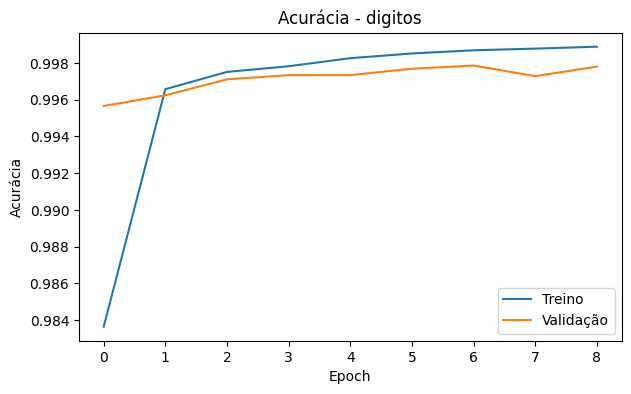

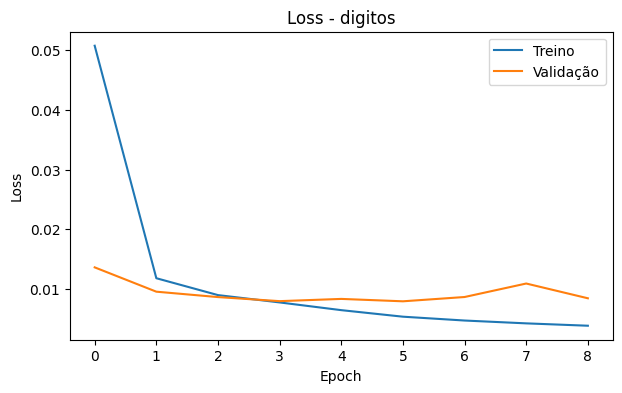

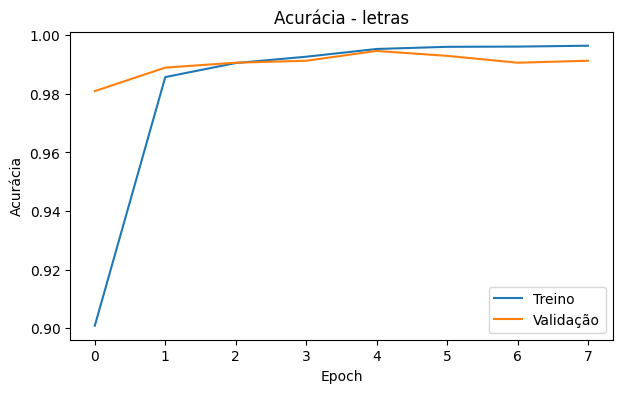

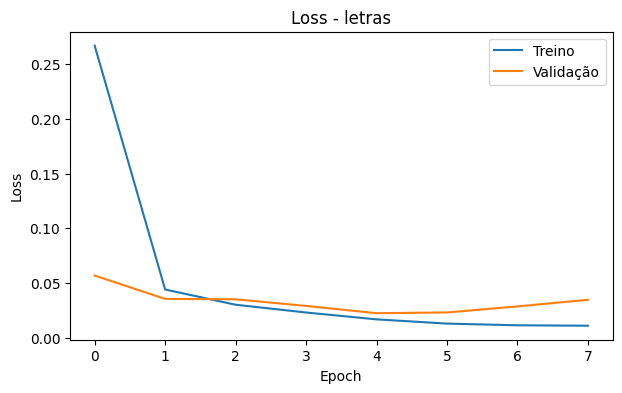

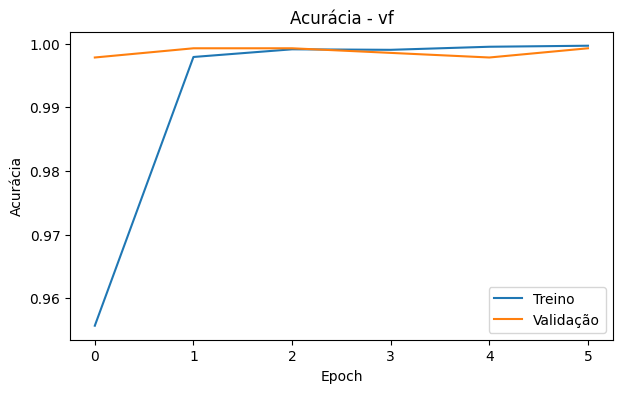

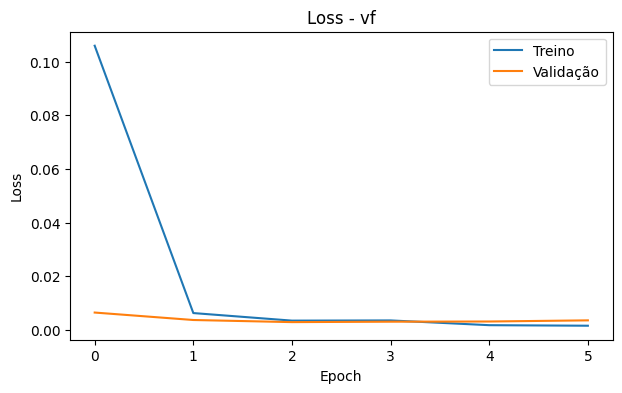

In [12]:
for nome, history in histories.items():

    plt.figure(figsize=(7,4))
    plt.plot(history.history["accuracy"], label="Treino")
    plt.plot(history.history["val_accuracy"], label="Validação")
    plt.xlabel("Epoch")
    plt.ylabel("Acurácia")
    plt.title(f"Acurácia - {nome}")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(history.history["loss"], label="Treino")
    plt.plot(history.history["val_loss"], label="Validação")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss - {nome}")
    plt.legend()
    plt.show()


DIGITOS
Acurácia de teste: 0.9971 (99.71%)
              precision    recall  f1-score   support

           1     0.9983    0.9987    0.9985      6330
           2     0.9949    0.9968    0.9958      5869
           3     0.9970    0.9948    0.9959      5969
           4     0.9984    0.9986    0.9985      5619
           5     0.9971    0.9967    0.9969      5190

    accuracy                         0.9971     28977
   macro avg     0.9971    0.9971    0.9971     28977
weighted avg     0.9971    0.9971    0.9971     28977



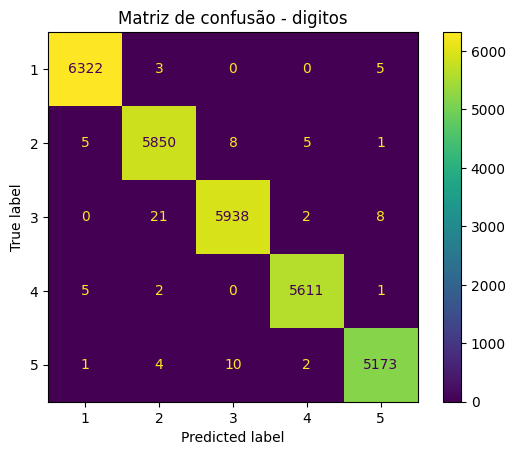


LETRAS
Acurácia de teste: 0.9919 (99.19%)
              precision    recall  f1-score   support

           A     0.9962    0.9896    0.9929      1062
           B     0.9937    0.9784    0.9860       648
           C     0.9926    0.9971    0.9948      1739
           D     0.9774    1.0000    0.9886       779
           E     0.9976    0.9871    0.9923       851

    accuracy                         0.9919      5079
   macro avg     0.9915    0.9904    0.9909      5079
weighted avg     0.9920    0.9919    0.9919      5079



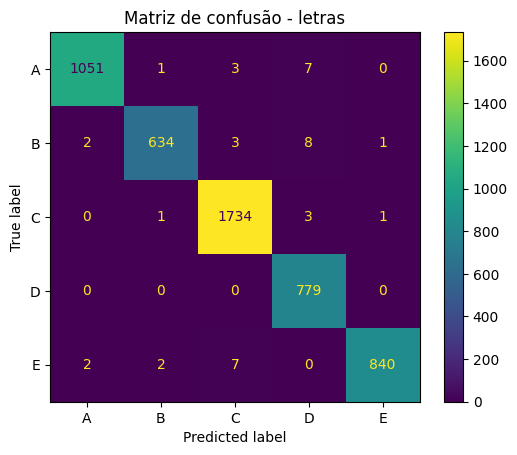


VF
Acurácia de teste: 0.9996 (99.96%)
              precision    recall  f1-score   support

           V     0.9987    1.0000    0.9994       796
           F     1.0000    0.9993    0.9997      1440

    accuracy                         0.9996      2236
   macro avg     0.9994    0.9997    0.9995      2236
weighted avg     0.9996    0.9996    0.9996      2236



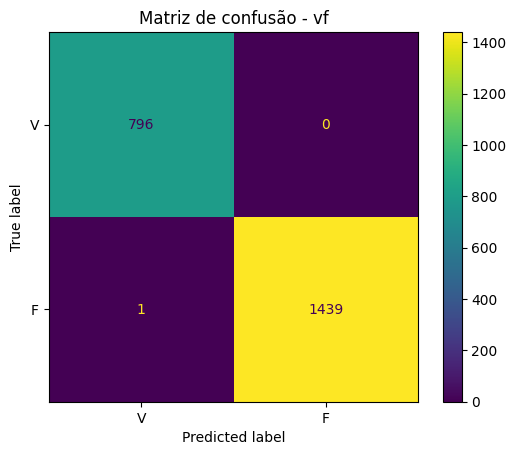

In [13]:
resultados = []

for nome, model in models.items():

    x_test = datasets[nome]["x_test"]
    y_test = datasets[nome]["y_test"]

    loss, acc = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    y_prob = model.predict(
        x_test,
        verbose=0
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    print("\n", "="*70)
    print(nome.upper())
    print(f"Acurácia de teste: {acc:.4f} ({acc*100:.2f}%)")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=CLASS_CONFIGS[nome]["names"],
            digits=4
        )
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_CONFIGS[nome]["names"]
    ).plot(values_format="d")

    plt.title(
        f"Matriz de confusão - {nome}"
    )

    plt.show()

    resultados.append({
        "Modelo": nome,
        "Acurácia": acc
    })

In [14]:
for nome, model in models.items():

    filename = f"cnn_{nome}_multiprova.keras"

    model.save(filename)

    print(
        nome,
        "salvo como",
        filename
    )

digitos salvo como cnn_digitos_multiprova.keras
letras salvo como cnn_letras_multiprova.keras
vf salvo como cnn_vf_multiprova.keras


In [15]:
summary_rows = []

for nome, model in models.items():

    filename = f"cnn_{nome}_multiprova.keras"

    trainable_params = int(
        np.sum([
            np.prod(v.shape)
            for v in model.trainable_weights
        ])
    )

    size_mb = (
        os.path.getsize(filename)
        / (1024**2)
    )

    x_test = datasets[nome]["x_test"]
    y_test = datasets[nome]["y_test"]

    _, acc = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    summary_rows.append({
        "Modelo": nome,
        "Classes": ", ".join(
            CLASS_CONFIGS[nome]["names"]
        ),
        "Acurácia_teste": acc,
        "Parâmetros_treináveis": trainable_params,
        "Tamanho_MB": size_mb
    })

summary_df = pd.DataFrame(summary_rows)

display(summary_df)

,Modelo,Classes,Acurácia_teste,Parâmetros_treináveis,Tamanho_MB
0,digitos,"1, 2, 3, 4, 5",0.997136,69477,0.845287
1,letras,"A, B, C, D, E",0.991928,69477,0.845299
2,vf,"V, F",0.999553,65122,0.788554


In [16]:
tflite_rows = []

for nome, model in models.items():

    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    converter.optimizations = [
        tf.lite.Optimize.DEFAULT
    ]

    tflite_model = converter.convert()

    tflite_name = (
        f"cnn_{nome}_multiprova_quant.tflite"
    )

    with open(
        tflite_name,
        "wb"
    ) as f:
        f.write(tflite_model)

    keras_size = (
        os.path.getsize(
            f"cnn_{nome}_multiprova.keras"
        )
        / (1024**2)
    )

    tflite_size = (
        os.path.getsize(
            tflite_name
        )
        / (1024**2)
    )

    reducao = 100 * (
        1 - tflite_size / keras_size
    )

    tflite_rows.append({
        "Modelo": nome,
        "Keras_MB": keras_size,
        "TFLite_MB": tflite_size,
        "Redução_%": reducao
    })

display(
    pd.DataFrame(tflite_rows)
)

Saved artifact at '/tmp/tmpso2mfpxm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  132780421111760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132780450182736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132780421038544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132780421046224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132780421044880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132780421046608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132780421050640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132780421038160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132780421040272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132780421040656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132780421040464:

,Modelo,Keras_MB,TFLite_MB,Redução_%
0,digitos,0.845287,0.076401,90.961564
1,letras,0.845299,0.076431,90.958076
2,vf,0.788554,0.070221,91.094975
